In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd

1. Load dataset

In [ ]:
df = pd.read_csv('kidney_disease.csv')
df.drop('id', axis=1, inplace=True)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [5]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [6]:
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [7]:
df.columns = ['age','blood_pressure','specific_gravity','albumin','sugar','red_blood_cells','pus_cell',
              'pus_cell_clumps','bacteria','blood_glucose_random','blood_urea','serum_creatinine','sodium',
              'potassium','haemoglobin','packed_cell_volume','white_blood_cell_count','red_blood_cell_count',
              'hypertension','diabetes_mellitus','coronary_artery_disease','appetite','peda_edema',
              'anemia','class']


3. Convert text columns to numeric

In [ ]:
text_cols = ['packed_cell_volume','white_blood_cell_count','red_blood_cell_count']
df[text_cols] = df[text_cols].apply(pd.to_numeric, errors='coerce')

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False).head(20)

red_blood_cells           152
red_blood_cell_count      131
white_blood_cell_count    106
potassium                  88
sodium                     87
packed_cell_volume         71
pus_cell                   65
haemoglobin                52
sugar                      49
specific_gravity           47
albumin                    46
blood_glucose_random       44
blood_urea                 19
serum_creatinine           17
blood_pressure             12
age                         9
bacteria                    4
pus_cell_clumps             4
hypertension                2
diabetes_mellitus           2
dtype: int64

4. Handle missing values

In [ ]:
num_cols = df.select_dtypes(exclude='object').columns
cat_cols = df.select_dtypes(include='object').columns

df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.mean()))
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False).head(20)

Series([], dtype: int64)

In [10]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.000000,...,44.0,7800.0,5.200000,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,148.036517,...,38.0,6000.0,4.707435,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.000000,...,31.0,7500.0,4.707435,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.000000,...,32.0,6700.0,3.900000,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.000000,...,35.0,7300.0,4.600000,no,no,no,good,no,no,ckd


In [11]:
print(f"diabetes_mellitus: {df['diabetes_mellitus'].unique()}")
print(f"coronary_artery_disease: {df['coronary_artery_disease'].unique()}")
print(f"class : {df['class'].unique()}")

diabetes_mellitus: ['yes' 'no' ' yes' '\tno' '\tyes']
coronary_artery_disease: ['no' 'yes' '\tno']
class : ['ckd' 'ckd\t' 'notckd']


In [12]:
# Clean text columns safely
df['diabetes_mellitus'] = df['diabetes_mellitus'].astype(str).str.strip()
df['coronary_artery_disease'] = df['coronary_artery_disease'].astype(str).str.strip()
df['class'] = df['class'].astype(str).str.strip()

# Standardize class names
df['class'] = df['class'].replace({'notckd': 'not ckd'})

# Check unique values
print(f"diabetes_mellitus: {df['diabetes_mellitus'].unique()}")
print(f"coronary_artery_disease: {df['coronary_artery_disease'].unique()}")
print(f"class : {df['class'].unique()}")


diabetes_mellitus: ['yes' 'no']
coronary_artery_disease: ['no' 'yes']
class : ['ckd' 'not ckd']


5. Encode categorical variables

In [ ]:
mapping = {
    'class': {'ckd': 1, 'not ckd': 0},
    'red_blood_cells': {'normal': 1, 'abnormal': 0},
    'pus_cell': {'normal': 1, 'abnormal': 0},
    'pus_cell_clumps': {'present': 1, 'notpresent': 0},
    'bacteria': {'present': 1, 'notpresent': 0},
    'hypertension': {'yes': 1, 'no': 0},
    'diabetes_mellitus': {'yes': 1, 'no': 0},
    'coronary_artery_disease': {'yes': 1, 'no': 0},
    'appetite': {'good': 1, 'poor': 0},
    'peda_edema': {'yes': 1, 'no': 0},
    'anemia': {'yes': 1, 'no': 0}
}
df = df.replace(mapping)
df.head()

/var/folders/yg/hzn_dgcd4gg0xz3qrfr78d640000gn/T/ipykernel_1823/4228070219.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.000000,...,44.0,7800.0,5.200000,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,148.036517,...,38.0,6000.0,4.707435,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.000000,...,31.0,7500.0,4.707435,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.000000,...,32.0,6700.0,3.900000,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.000000,...,35.0,7300.0,4.600000,0,0,0,1,0,0,1


6. Handle outliers (IQR method)

In [ ]:
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


In [15]:
# Check all object-type columns for unique values
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")


7. Correlation heatmap

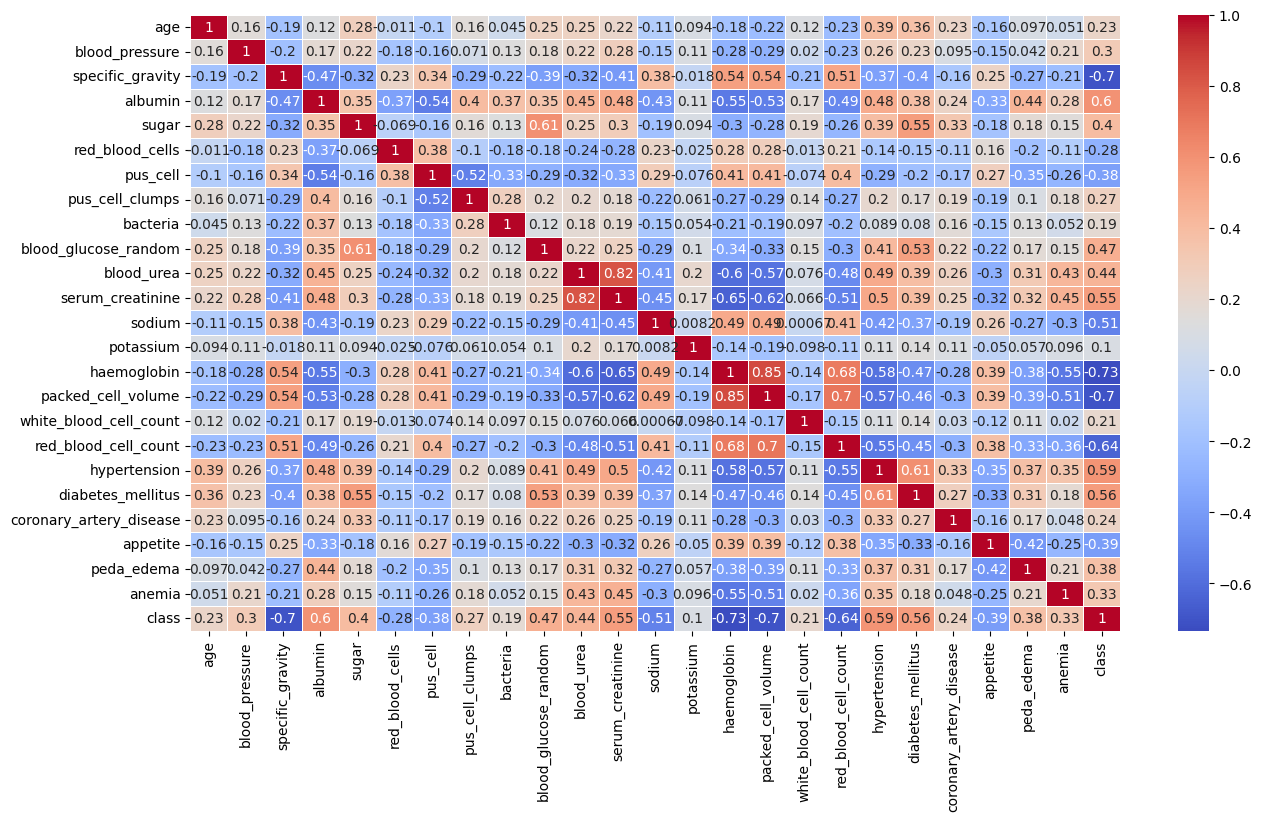

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True, linewidths=0.5, cmap="coolwarm")
plt.show()

In [17]:
target_corr = df.corr()['class'].abs().sort_values(ascending=False)[1:]
target_corr

df['class'].value_counts()

class
1    250
0    150
Name: count, dtype: int64

8. Train-test split

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=25)

print(f"'X' shape: {X_train.shape}")
print(f"'Xtest' shape: {X_test.shape}")

'X' shape: (300, 24)
'Xtest' shape: (100, 24)


9. Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

y_pred_dtc = dtc.predict(X_test)
y_pred_dtc

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1])

10.Models

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = []
models.append(('Naive Bayes', GaussianNB()))
models.append(('KNN', KNeighborsClassifier(n_neighbors=8)))
models.append(('RandomForestClassifier', RandomForestClassifier()))
models.append(('DecisionTreeClassifier', DecisionTreeClassifier()))
models.append(('SVM', SVC(kernel='linear')))

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 12. Model evaluation with confusion matrix plots
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"----- {name} -----")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.2f}\n")
    

----- Naive Bayes -----
Confusion Matrix:
 [[37  0]
 [ 6 57]]
Accuracy: 0.94
Precision: 1.00
Recall: 0.90
F1 Score: 0.95

----- KNN -----
Confusion Matrix:
 [[37  0]
 [ 5 58]]
Accuracy: 0.95
Precision: 1.00
Recall: 0.92
F1 Score: 0.96

----- RandomForestClassifier -----
Confusion Matrix:
 [[35  2]
 [ 0 63]]
Accuracy: 0.98
Precision: 0.97
Recall: 1.00
F1 Score: 0.98

----- DecisionTreeClassifier -----
Confusion Matrix:
 [[35  2]
 [ 1 62]]
Accuracy: 0.97
Precision: 0.97
Recall: 0.98
F1 Score: 0.98

----- SVM -----
Confusion Matrix:
 [[35  2]
 [ 2 61]]
Accuracy: 0.96
Precision: 0.97
Recall: 0.97
F1 Score: 0.97



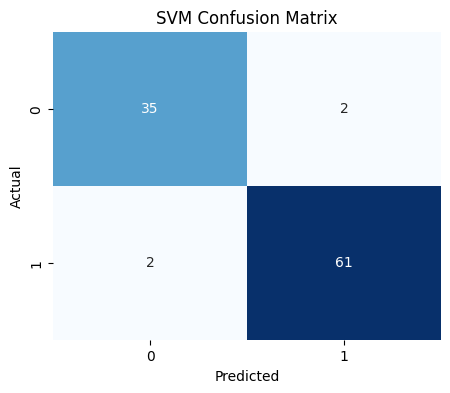

In [22]:
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [23]:
import pickle

# Example: save the Random Forest model (you can change it to your best model)
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

# Save the model
with open("ckd_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("✅ Model saved as ckd_model.pkl")


✅ Model saved as ckd_model.pkl


In [24]:
# Load the model
with open("ckd_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Test prediction with X_test
y_pred_loaded = loaded_model.predict(X_test[:5])  # check first 5 samples
print("✅ Loaded model predictions:", y_pred_loaded)
print("✅ Actual values:", y_test[:5].values)


✅ Loaded model predictions: [1 1 0 0 0]
✅ Actual values: [1 1 0 0 0]
